# Qiskit Assignment

## Tasks

1. Create a 2-qubit quantum circuit with a 90° phase shift and visualize it using the Q-sphere.
2. Create a circuit in QASM, import it into Qiskit, and run it.
3. Draw any random circuit, but do not use the dump method.


In [1]:
from math import pi

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_state_qsphere, plot_histogram
from qiskit_aer import AerSimulator
from IPython.display import display

import matplotlib.pyplot as plt


## Task 1: 2-qubit quantum circuit with a 90° phase shift

A 90° phase shift can be represented by `p(pi / 2, qubit)`.

`pi / 2` radians equals 90 degrees.

The Hadamard gate is applied first so that the phase shift becomes visible in the quantum state.


Circuit text:
     ┌───┐┌────────┐
q_0: ┤ H ├┤ P(π/2) ├
     └───┘└────────┘
q_1: ───────────────
                    


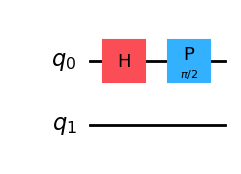

Statevector:
Statevector([7.07106781e-01+0.j        , 4.32978028e-17+0.70710678j,
             0.00000000e+00+0.j        , 0.00000000e+00+0.j        ],
            dims=(2, 2))


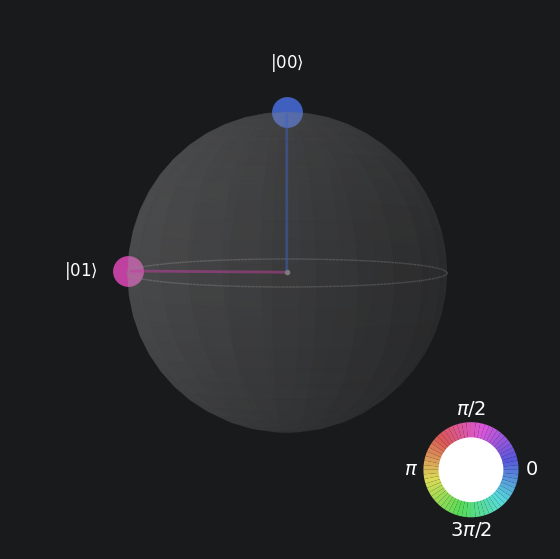

In [2]:
qc_phase = QuantumCircuit(2)

# Put qubit 0 into superposition first
qc_phase.h(0)

# Apply 90 degree phase shift to qubit 0
qc_phase.p(pi / 2, 0)

print('Circuit text:')
print(qc_phase.draw(output='text'))

phase_circuit_fig = qc_phase.draw(output='mpl')
display(phase_circuit_fig)
plt.close(phase_circuit_fig)

state_phase = Statevector.from_instruction(qc_phase)

print('Statevector:')
print(state_phase)

qsphere_fig = plot_state_qsphere(state_phase)
display(qsphere_fig)
plt.close(qsphere_fig)


## Task 2: Create a circuit in QASM, import it, and run it in Qiskit

This QASM code creates a Bell state using an H gate and a CX gate.

The result should mainly contain `00` and `11` because the two qubits are entangled.


Imported QASM circuit:
     ┌───┐     ┌─┐   
q_0: ┤ H ├──■──┤M├───
     └───┘┌─┴─┐└╥┘┌─┐
q_1: ─────┤ X ├─╫─┤M├
          └───┘ ║ └╥┘
c: 2/═══════════╩══╩═
                0  1 


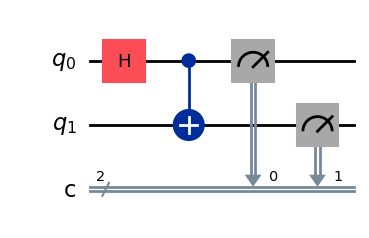

Measurement result:
{'00': 523, '11': 501}


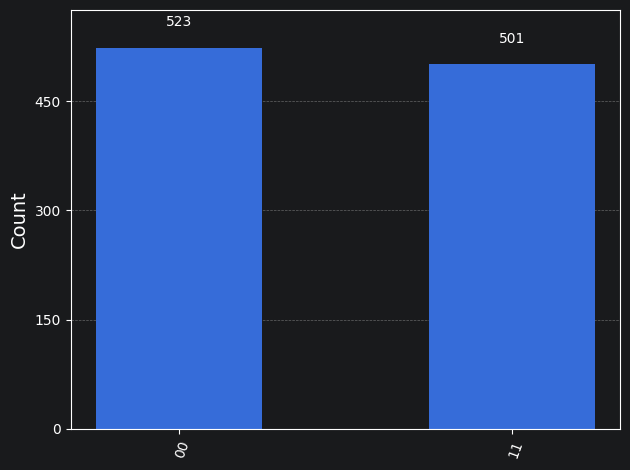

In [3]:
qasm_code = """
OPENQASM 2.0;
include "qelib1.inc";

qreg q[2];
creg c[2];

h q[0];
cx q[0], q[1];

measure q[0] -> c[0];
measure q[1] -> c[1];
"""

qc_qasm = QuantumCircuit.from_qasm_str(qasm_code)

print('Imported QASM circuit:')
print(qc_qasm.draw(output='text'))

qasm_circuit_fig = qc_qasm.draw(output='mpl')
display(qasm_circuit_fig)
plt.close(qasm_circuit_fig)

simulator = AerSimulator()
job = simulator.run(qc_qasm, shots=1024)
result = job.result()
counts = result.get_counts()

print('Measurement result:')
print(counts)

hist_fig = plot_histogram(counts)
display(hist_fig)
plt.close(hist_fig)


## Task 3: Draw any random circuit, but do not use dump method

This task uses `draw()` to display the circuit.

No `dump()` method is used.


Random circuit text:
     ┌───┐     ┌───┐   ┌─┐   
q_0: ┤ H ├──■──┤ Z ├───┤M├───
     ├───┤  │  ├───┤┌─┐└╥┘   
q_1: ┤ X ├──┼──┤ T ├┤M├─╫────
     └───┘┌─┴─┐├───┤└╥┘ ║ ┌─┐
q_2: ─────┤ X ├┤ S ├─╫──╫─┤M├
          └───┘└───┘ ║  ║ └╥┘
c: 3/════════════════╩══╩══╩═
                     1  0  2 


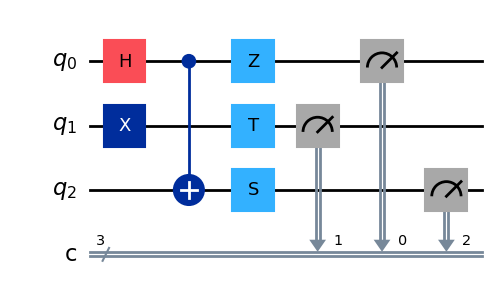

In [4]:
qc_random = QuantumCircuit(3, 3)

qc_random.h(0)
qc_random.x(1)
qc_random.cx(0, 2)
qc_random.s(2)
qc_random.t(1)
qc_random.z(0)
qc_random.measure([0, 1, 2], [0, 1, 2])

# Draw circuit using draw(), not dump()
print('Random circuit text:')
print(qc_random.draw(output='text'))

random_circuit_fig = qc_random.draw(output='mpl')
display(random_circuit_fig)
plt.close(random_circuit_fig)


## Simple checks

These checks confirm that the circuits were created with the expected number of qubits.


In [5]:
assert qc_phase.num_qubits == 2
assert qc_qasm.num_qubits == 2
assert qc_random.num_qubits == 3

print('All tasks completed successfully.')


All tasks completed successfully.
